# Analyse exploratoire des données

In [7]:
import pandas as pd

df = pd.read_csv("train.csv")

print("Dimensions :", df.shape)
print("\nColonnes :", df.columns.tolist())

print("\nInformations :")
df.info()

print("\nValeurs manquantes :")
print(df.isna().sum())

df.head()

Dimensions : (50000, 33)

Colonnes : ['index', 'id_client', 'id_vehicule', 'id_contrat', 'bonus', 'type_contrat', 'duree_contrat', 'anciennete_info', 'freq_paiement', 'paiement', 'utilisation', 'code_postal', 'conducteur2', 'age_conducteur1', 'age_conducteur2', 'sex_conducteur1', 'sex_conducteur2', 'anciennete_permis1', 'anciennete_permis2', 'anciennete_vehicule', 'cylindre_vehicule', 'din_vehicule', 'essence_vehicule', 'marque_vehicule', 'modele_vehicule', 'debut_vente_vehicule', 'fin_vente_vehicule', 'vitesse_vehicule', 'type_vehicule', 'prix_vehicule', 'poids_vehicule', 'nombre_sinistres', 'montant_sinistre']

Informations :
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 50000 non-null  int64  
 1   id_client             50000 non-null  str    
 2   id_vehicule           50000 non-null  str    
 3   id_con

,index,id_client,id_vehicule,id_contrat,bonus,type_contrat,duree_contrat,anciennete_info,freq_paiement,paiement,...,marque_vehicule,modele_vehicule,debut_vente_vehicule,fin_vente_vehicule,vitesse_vehicule,type_vehicule,prix_vehicule,poids_vehicule,nombre_sinistres,montant_sinistre
0,0,A00000001,V01,A00000001-V01,0.5,Maxi,29,9,Biannual,No,...,PEUGEOT,306,10,9,182,Tourism,20700,1210,0,0.0
1,1,A00000002,V01,A00000002-V01,0.5,Maxi,3,1,Biannual,No,...,MERCEDES BENZ,C220,4,2,229,Tourism,34250,1510,0,0.0
2,2,A00000003,V01,A00000003-V01,0.5,Maxi,2,2,Yearly,No,...,BMW,Z3,12,11,210,Tourism,28661,1270,0,0.0
3,3,A00000004,V01,A00000004-V01,0.5,Median2,22,1,Yearly,No,...,VOLKSWAGEN,GOLF,18,15,180,Tourism,14407,1020,0,0.0
4,4,A00000005,V01,A00000005-V01,0.5,Maxi,16,4,Biannual,No,...,RENAULT,LAGUNA,13,11,195,Tourism,16770,1230,0,0.0


In [12]:
sinistres = df["nombre_sinistres"]

print("Statistiques descriptives :")
print(sinistres.describe())

distribution = pd.DataFrame({
    "Effectif": sinistres.value_counts(dropna=False),
    "Pourcentage (%)": sinistres.value_counts(
        normalize=True, dropna=False
    ).mul(100).round(2)
}).sort_index()

distribution.index.name = "nombre_sinistre"

distribution



Statistiques descriptives :
count    50000.000000
mean         0.058340
std          0.234388
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: nombre_sinistres, dtype: float64


,Effectif,Pourcentage (%)
nombre_sinistre,,
0,47083,94.17
1,2917,5.83


In [15]:
# Statistiques pour les colonnes numériques
numeriques = df.select_dtypes(include="number")

stats = numeriques.describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
).T.rename(columns={
    "count": "Non nulles",
    "mean": "Moyenne",
    "std": "Écart-type",
    "min": "Min",
    "1%": "P1",
    "25%": "Q1",
    "50%": "Médiane",
    "75%": "Q3",
    "99%": "P99",
    "max": "Max"
})

# Informations pour toutes les colonnes
resume = pd.DataFrame(index=df.columns)
resume["Type"] = df.dtypes.astype(str)
resume["Manquantes"] = df.isna().sum()
resume["Manquantes (%)"] = df.isna().mean() * 100
resume["Valeurs distinctes"] = df.nunique()

# Regrouper les informations dans un seul tableau
resume = resume.join(stats)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

resume.round(2)

,Type,Manquantes,Manquantes (%),Valeurs distinctes,Non nulles,Moyenne,Écart-type,Min,P1,Q1,Médiane,Q3,P99,Max
index,int64,0,0.00,50000,50000.0,24999.50,14433.90,0.0,499.99,12499.75,24999.5,37499.25,49499.01,49999.00
id_client,str,0,0.00,45785,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_vehicule,str,0,0.00,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_contrat,str,0,0.00,50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bonus,float64,0,0.00,73,50000.0,0.54,0.10,0.5,0.50,0.50,0.5,0.50,0.95,2.16
type_contrat,str,0,0.00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duree_contrat,int64,0,0.00,41,50000.0,11.09,8.57,1.0,1.00,4.00,9.0,16.00,31.00,41.00
anciennete_info,int64,0,0.00,25,50000.0,2.73,2.35,1.0,1.00,1.00,2.0,3.00,12.00,25.00
freq_paiement,str,0,0.00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
paiement,str,0,0.00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Statistiques pour les colonnes numériques
numeriques = df.select_dtypes(include="number")

stats = numeriques.describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
).T.rename(columns={
    "count": "Non nulles",
    "mean": "Moyenne",
    "std": "Écart-type",
    "min": "Min",
    "1%": "P1",
    "25%": "Q1",
    "50%": "Médiane",
    "75%": "Q3",
    "99%": "P99",
    "max": "Max"
})

# Informations pour toutes les colonnes
resume = pd.DataFrame(index=df.columns)
resume["Type"] = df.dtypes.astype(str)
resume["Manquantes"] = df.isna().sum()
resume["Manquantes (%)"] = df.isna().mean() * 100
resume["Valeurs distinctes"] = df.nunique()

# Regrouper les informations dans un seul tableau
resume = resume.join(stats)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

resume.round(2)

,Type,Manquantes,Manquantes (%),Valeurs distinctes,Non nulles,Moyenne,Écart-type,Min,P1,Q1,Médiane,Q3,P99,Max
index,int64,0,0.00,50000,50000.0,24999.50,14433.90,0.0,499.99,12499.75,24999.5,37499.25,49499.01,49999.00
id_client,str,0,0.00,45785,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_vehicule,str,0,0.00,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_contrat,str,0,0.00,50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bonus,float64,0,0.00,73,50000.0,0.54,0.10,0.5,0.50,0.50,0.5,0.50,0.95,2.16
type_contrat,str,0,0.00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duree_contrat,int64,0,0.00,41,50000.0,11.09,8.57,1.0,1.00,4.00,9.0,16.00,31.00,41.00
anciennete_info,int64,0,0.00,25,50000.0,2.73,2.35,1.0,1.00,1.00,2.0,3.00,12.00,25.00
freq_paiement,str,0,0.00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
paiement,str,0,0.00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


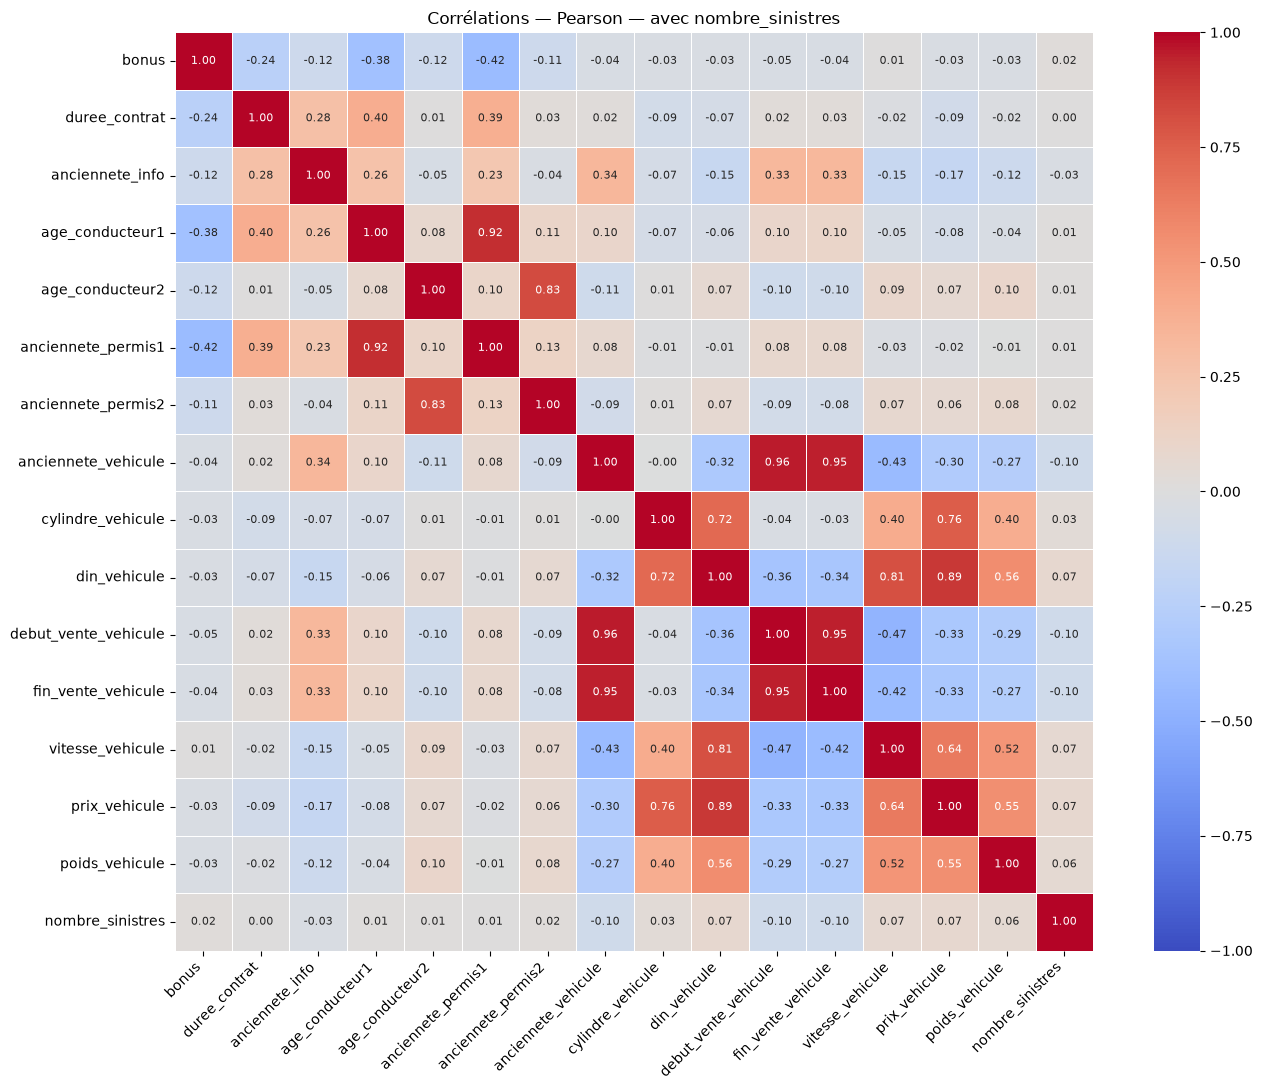

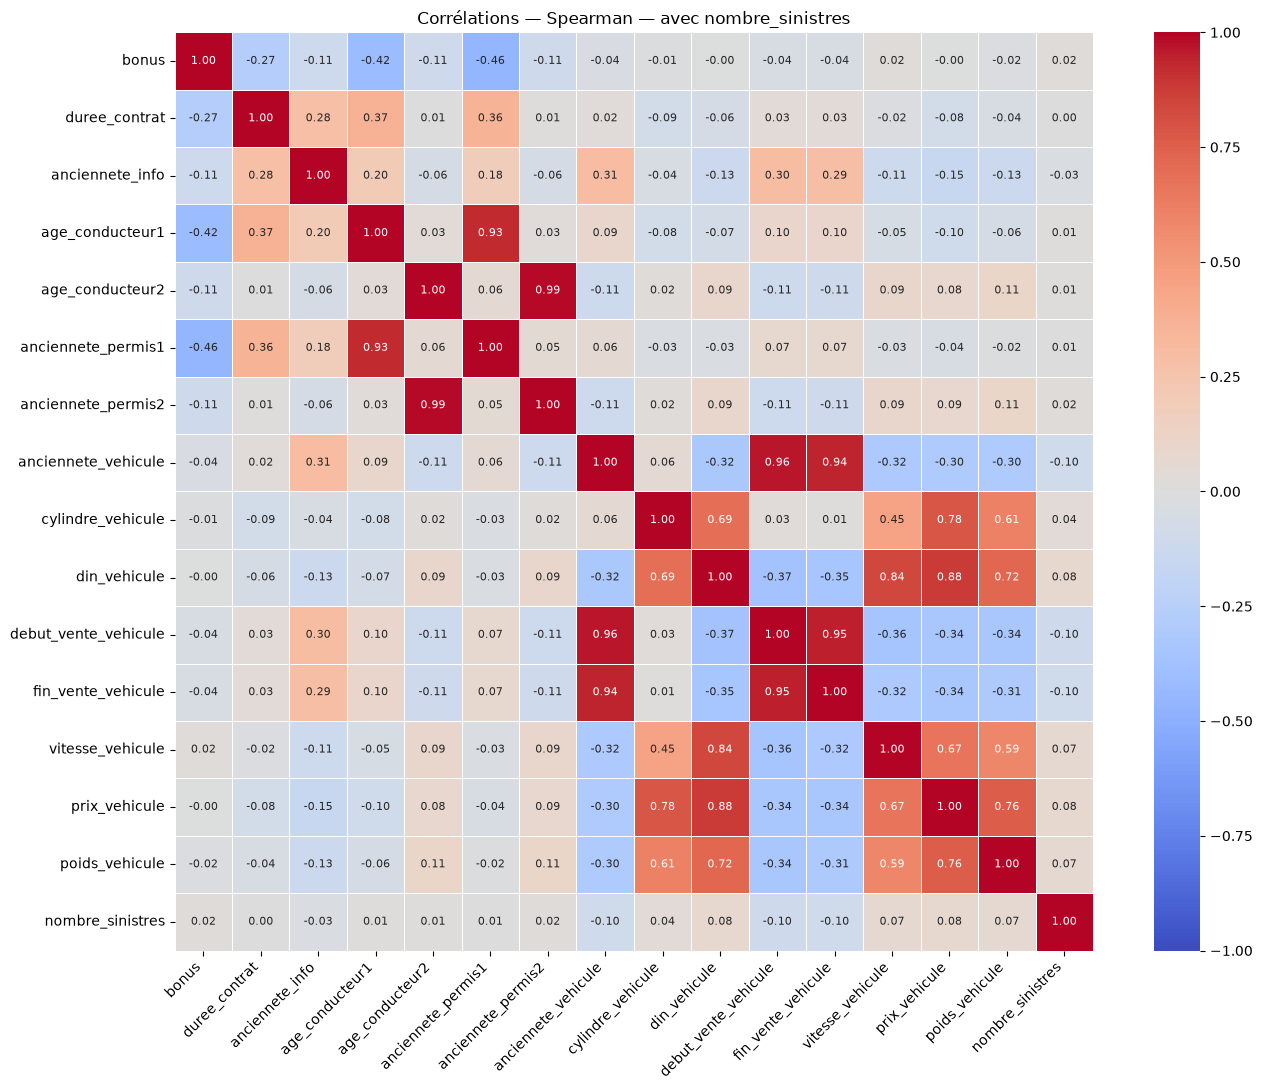

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables explicatives + nombre de sinistres
df_analyse = df[colonnes_mesures + ["nombre_sinistres"]].copy()

# Une figure pour chaque méthode
for methode in ["pearson", "spearman"]:
    correlation = df_analyse.corr(method=methode)

    plt.figure(figsize=(14, 11))

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        annot_kws={"size": 8}
    )

    plt.title(f"Corrélations — {methode.capitalize()} — avec nombre_sinistres")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

Les classes (sinistré / non sinistré) sont-elles équilibrées ? Quelles conséquences pour le
choix de la métrique ?

Certaines variables pourraient-elles contenir une information indisponible au moment de
la tarification (fuite de données) ?